In [1]:
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

from project_package.visualization import Model_Visualizer
from project_package import utility

g:\Python\envs\learning_env\lib\site-packages\dask\dataframe\__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


Regression test

In [2]:
test_data = utility.generate_data('diabetes',0.2,seed=0)
X_train, X_test, y_train, y_test = utility.generate_data('diabetes',0.2,seed=0,binary_label=True) 

In [3]:
vis_obj = Model_Visualizer(*test_data)
ridge = Ridge(alpha=1).fit(X_train, y_train)

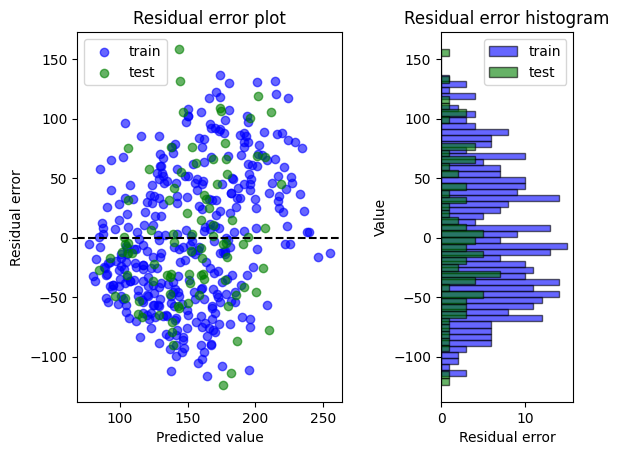

In [4]:
vis_obj.residual_plot(ridge,bins=50)

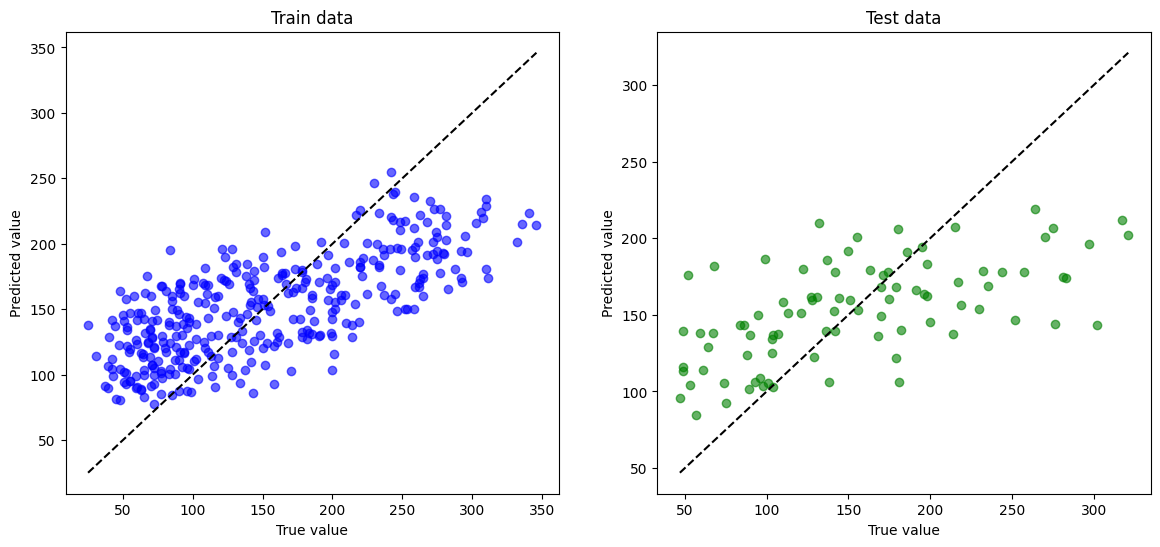

In [5]:
vis_obj.prediction_validate_plot(ridge)

Classification test

In [6]:
test_data = utility.generate_data('iris',0.3,seed=0,binary_label=True,add_random=True)
X_train, X_test, y_train, y_test = utility.generate_data('iris',0.3,seed=0,binary_label=True,add_random=True) 

vis_obj = Model_Visualizer(*test_data)

In [7]:
classifier = make_pipeline(StandardScaler(), LinearSVC(random_state=0))
classifier.fit(X_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(random_state=0))])

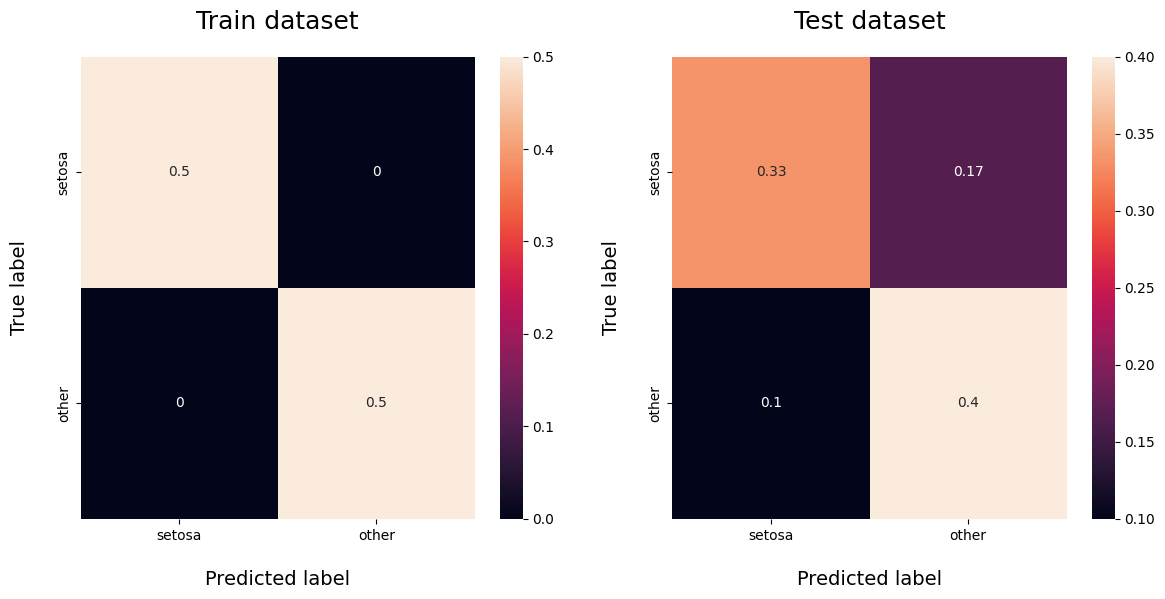

In [8]:
vis_obj.confusion_matrix(classifier,utility.get_target_label('iris',binary_label=True),normalize=True)

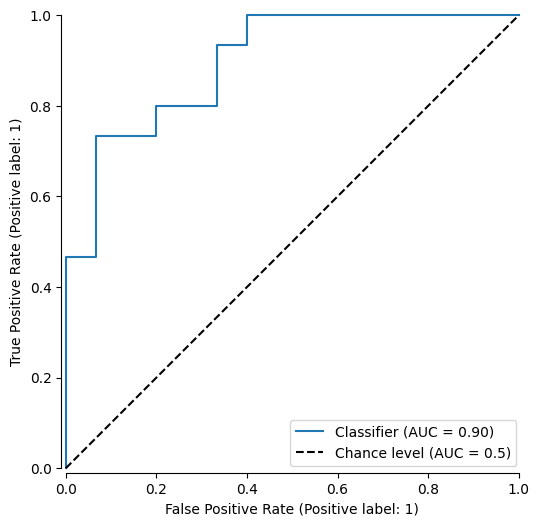

In [9]:
vis_obj.ROC_curve(y_test = y_test,y_score = classifier.decision_function(X_test))

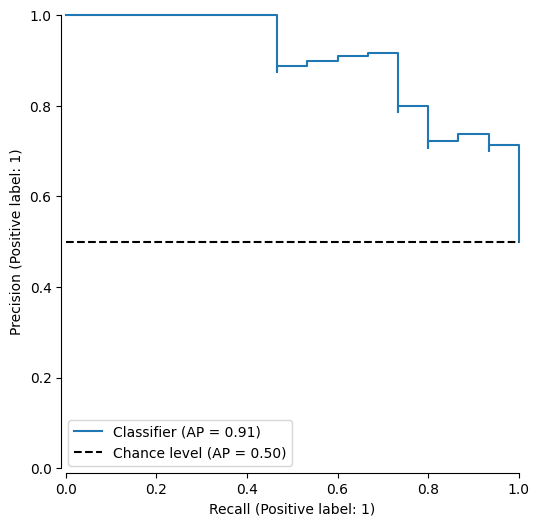

In [10]:
vis_obj.precision_recall_curve(y_test = y_test,y_score = classifier.decision_function(X_test))
plt.show()